#### Day 3- Linear regression: Predicting the spend based on time spent in coffee shop

#### **Importing Libraries**

In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats # for prob plot
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#### **Generating the dataset synthetically**

In [162]:
# Reproducibility
np.random.seed(42)

# Generate more time_spent data (from 1 to 60 minutes)
time_spent = np.linspace(1, 60, 100).reshape(-1, 1)  # 100 values

# Simulate money_spent using a linear relationship + some noise
money_spent = (3.5 * time_spent.flatten()) + np.random.normal(0, 15, size=time_spent.shape[0])

# Wrap it in a DataFrame 
df = pd.DataFrame({
    'Time_Spent': time_spent.flatten(),
    'Money_Spent': money_spent
})

print(df.head())

   Time_Spent  Money_Spent
0    1.000000    10.950712
1    1.595960     3.511894
2    2.191919    17.387045
3    2.787879    32.603024
4    3.383838     8.331134


#### **Train Test split**

In [163]:
#Create training data as DataFrame
X = df[['Time_Spent']]
y = df['Money_Spent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### **Model Training**

In [164]:
# Model Training
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [154]:
model.coef_

array([3.53072213])

In [155]:
model.intercept_

np.float64(-2.7339439305135897)

#### **Model Prediction**

In [156]:
y_pred = model.predict(X_test)



#### **Metrics- RMSE and R square**

In [157]:
# Metrics
predict_train = model.predict(X_train)

mse = mean_squared_error(y_train, predict_train)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, predict_train)

print("RMSE:", mse)
print("R² Score:", r2* 100,"%")

RMSE: 194.2805936370084
R² Score: 94.9982245750526 %


### REGRESSION LINE PLOT

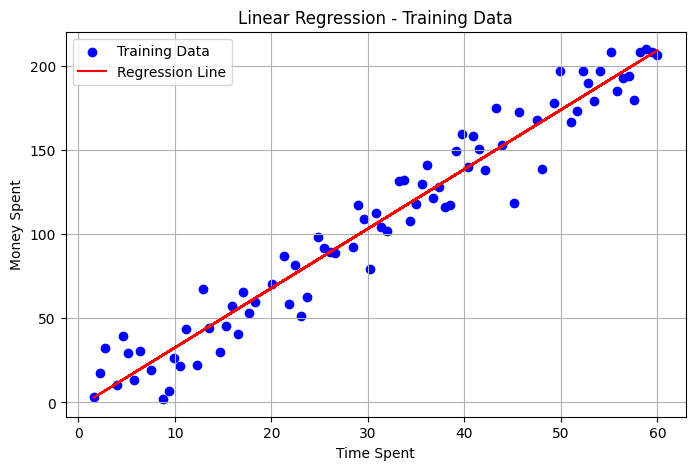

In [158]:
plt.figure(figsize = (8,5))
plt.scatter(X_train, y_train,color='blue',label='Training Data')
plt.plot(X_train, model.predict(X_train), color='red', label='Regression Line')
plt.xlabel('Time Spent')
plt.ylabel('Money Spent')
plt.title('Linear Regression - Training Data')
plt.legend()
plt.grid(True)
plt.show()

### THIS PLOT SHOWS THAT X AND Y FOLLOWS THE LINEAR RELATION

### **Prediction vs Actual**

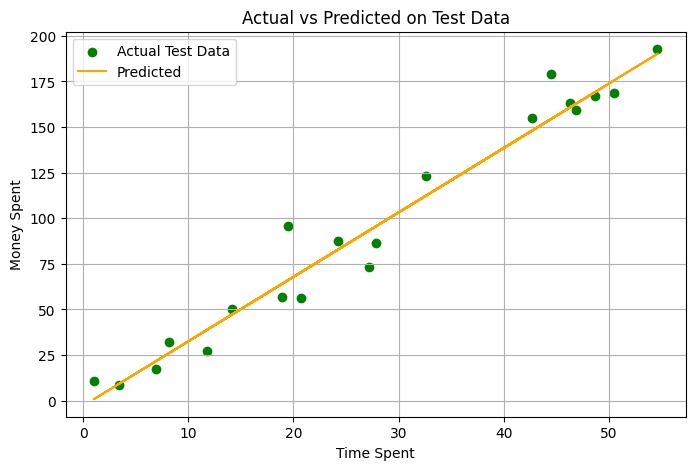

In [166]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='green', label='Actual Test Data')
plt.plot(X_test, y_pred, color='orange', label='Predicted')
plt.xlabel('Time Spent')
plt.ylabel('Money Spent')
plt.title('Actual vs Predicted on Test Data')
plt.legend()
plt.grid(True)
plt.show()

#### **Residual Plot**

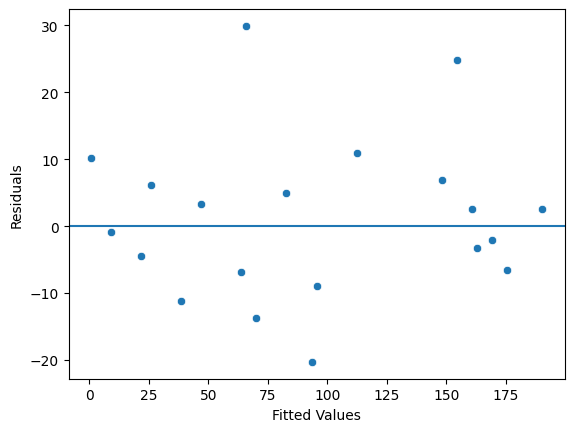

In [170]:
residuals = y_test - y_pred

fig = sns.scatterplot(x=y_pred, y=residuals)

# Add reference line at residuals = 0
fig.axhline(0)

# Set x-axis and y-axis labels
fig.set_xlabel("Fitted Values")
fig.set_ylabel("Residuals")

# Show the plot
plt.show()


#### It follows homoscedasticity - as residuals are scatteres randomly, hence this assumption is met

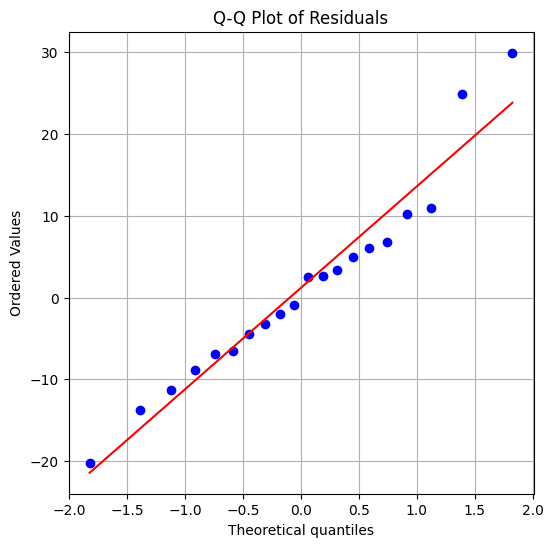

In [161]:
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid(True)
plt.show()

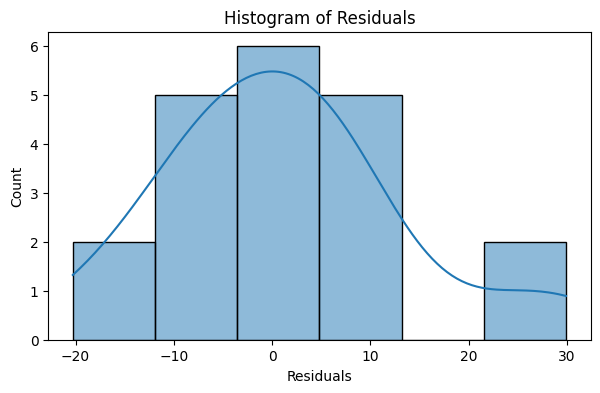

In [167]:
plt.figure(figsize=(7,4))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.show()


#### Assumption that residuals are normally distributed is met here

In [169]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw:.3f} (Close to 2 = good)")


Durbin-Watson statistic: 1.977 (Close to 2 = good)


#### The Durbin-Watson (DW) statistic tests whether there is autocorrelation (correlation between errors) in the residuals from a regression.

Autocorrelation can mess up your regression analysis because one residual may predict another, violating the assumption of independent errors.

📏 Durbin-Watson Value Range
DW Value	Interpretation
~2	✅ No autocorrelation (this is ideal!)
< 2	🔁 Positive autocorrelation (errors are repeating patterns)
> 2	🔄 Negative autocorrelation (errors are zig-zagging)